# Simulator Base Data â€” Bootstrap Generator

Generates `customers.csv`, `addresses.csv`, and `products.csv`.

**Key design decisions (ADR-018):**
- Primary `created_at` uses seasonal weights * linear acquisition decay (market maturation).
- Household member `created_at` uses blended seasonal+uniform*decay, bounded by primary date.
- Pool built once per type; per-row sampling uses bisect trim â€” no per-row rebuild.
- Window: 4 years back to 2 years forward.

In [1]:
import bisect
import random
import string
from datetime import datetime, timedelta, timezone
from time import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from faker import Faker

fake = Faker()

N_ADDRESSES    = 200_000
HOUSEHOLD_FRAC = 0.40
HOUSEHOLD_DIST = [0.50, 0.30, 0.15, 0.05]

WINDOW_START = datetime(2023, 6, 1, tzinfo=timezone.utc)
WINDOW_END   = datetime(2028, 6, 1, tzinfo=timezone.utc)
PRIMARY_DECAY_FLOOR = 0.40   # acquisition rate for primaries at window end (raise to preserve peaks)
HH_DECAY_FLOOR      = 0.05   # acquisition rate for households at window end (lower to cut right-end ramp)
HH_BLEND            = 0.50   # 0=fully seasonal, 1=fully flat

print(f'Window : {WINDOW_START.date()} -> {WINDOW_END.date()}')
print(f'Addresses target: {N_ADDRESSES:,}')


Window : 2023-06-01 -> 2028-06-01
Addresses target: 200,000


## Geographic sampling

In [2]:
zip_density = pd.read_csv('../samples/zip_density.csv')
zip_density['Zip'] = zip_density['Zip'].astype(str).str.zfill(5)

total_population = zip_density.population.sum()
total_dist = zip_density.groupby('State').population.sum() / total_population

def generate_samples(df, sample_size=100):
    idx = np.random.choice(df.index, size=sample_size, replace=True, p=df['weight'].values)
    s = df.loc[idx].copy()
    s['population'] = 1
    return s.drop(columns=['weight']).reset_index(drop=True)

t0 = time()
sample = generate_samples(zip_density, sample_size=N_ADDRESSES)
sample.columns = sample.columns.str.lower()
print(f'Geographic sample: {len(sample):,} rows in {time()-t0:.2f}s')


Geographic sample: 200,000 rows in 0.09s


## Seasonal weight functions with acquisition decay

In [3]:
_MONTHLY_WEIGHT = {
    1: 0.65, 2: 0.70, 3: 0.90, 4: 0.95,  5: 1.00,
    6: 1.05, 7: 1.10, 8: 1.05, 9: 1.00, 10: 1.10,
    11: 1.80, 12: 2.50,
}

def _seasonal_weight(dt):
    base = _MONTHLY_WEIGHT[dt.month]
    if dt.month == 12:
        if dt.day <= 15:   base *= 1.5
        elif dt.day <= 24: base *= 1.1
        else:              base *= 0.6
    return base

def _decay(dt, floor):
    """Linear decay from 1.0 at WINDOW_START to floor at WINDOW_END.
    Models market maturation. floor is passed explicitly so primary and
    household pools can decay at different rates.
    """
    total_days = (WINDOW_END - WINDOW_START).days
    elapsed    = max(0, (dt - WINDOW_START).days)
    return 1.0 - (1.0 - floor) * (elapsed / total_days)

def _build_primary_pool(start, end):
    days, weights = [], []
    cur = start.replace(hour=0, minute=0, second=0, microsecond=0)
    while cur < end:
        days.append(cur)
        weights.append(_seasonal_weight(cur) * _decay(cur, PRIMARY_DECAY_FLOOR))
        cur += timedelta(days=1)
    return days, weights

def _build_household_pool(start, end, blend=HH_BLEND):
    days, weights = [], []
    cur = start.replace(hour=0, minute=0, second=0, microsecond=0)
    while cur < end:
        days.append(cur)
        s = _seasonal_weight(cur) * _decay(cur, HH_DECAY_FLOOR)
        u = _decay(cur, HH_DECAY_FLOOR)
        weights.append(blend * s + (1 - blend) * u)
        cur += timedelta(days=1)
    return days, weights

_PRIMARY_DAYS,   _PRIMARY_W   = _build_primary_pool(WINDOW_START, WINDOW_END)
_HOUSEHOLD_DAYS, _HOUSEHOLD_W = _build_household_pool(WINDOW_START, WINDOW_END)

def _sample_primary(n):
    chosen = random.choices(_PRIMARY_DAYS, weights=_PRIMARY_W, k=n)
    return [d + timedelta(seconds=random.randint(0, 86_399)) for d in chosen]

def _sample_household(floor, n=1):
    """Sample from household pool at or after floor using bisect trim."""
    floor_day = floor.replace(hour=0, minute=0, second=0, microsecond=0)
    if floor_day.tzinfo is None:
        floor_day = floor_day.replace(tzinfo=timezone.utc)
    idx = bisect.bisect_left(_HOUSEHOLD_DAYS, floor_day)
    d_slice = _HOUSEHOLD_DAYS[idx:]
    w_slice = _HOUSEHOLD_W[idx:]
    if not d_slice:
        return [floor] * n
    chosen = random.choices(d_slice, weights=w_slice, k=n)
    return [d + timedelta(seconds=random.randint(0, 86_399)) for d in chosen]

print(f'Primary pool  : {len(_PRIMARY_DAYS):,} days')
print(f'Household pool: {len(_HOUSEHOLD_DAYS):,} days')


Primary pool  : 1,827 days
Household pool: 1,827 days


## Email generation

In [4]:
chars = string.ascii_lowercase + string.digits + '_.-'

def gen_email(r):
    first = r.first_name.lower()[:random.randint(1,15)] if random.random() < 0.3 else r.first_name.lower()
    last  = r.last_name.lower()[:random.randint(5,30)]  if random.random() < 0.5 else r.last_name.lower()
    sep   = random.choice('_.-') if random.random() < 0.75 and len(first) > 0 else ''
    noise = ''.join(random.choices(chars, k=random.randint(0,5))) if random.random() < 0.5 else ''
    domain = random.choices(
        [fake.free_email_domain, fake.safe_domain_name, fake.domain_name],
        weights=[.6, .3, .2]
    )[0]()
    return f'{first}{sep}{last}{noise}@{domain}'

def make_email(x, seen=None):
    if seen is None:
        seen = set()
    result = []
    for r in x.itertuples():
        email = gen_email(r)
        while email in seen:
            email = gen_email(r)
        seen.add(email)
        result.append(email)
    return result

print('Email helpers ready')


Email helpers ready


## Generate primary customers (one per address)

In [5]:
t0 = time()

primary_dates = _sample_primary(len(sample))

dataset = sample.assign(
    street_address = lambda x: [fake.street_address() for _ in range(len(x))],
    first_name     = lambda x: [fake.first_name()     for _ in range(len(x))],
    last_name      = lambda x: [fake.last_name()      for _ in range(len(x))],
    address_id     = lambda x: [f'addr_{fake.uuid4(cast_to=None).hex[:12]}' for _ in range(len(x))],
    customer_id    = lambda x: [f'cust_{fake.uuid4(cast_to=None).hex[:12]}' for _ in range(len(x))],
    created_at     = pd.Series(
        [d.strftime('%Y-%m-%dT%H:%M:%S+00:00') for d in primary_dates],
        index=sample.index
    ),
)
dataset = dataset.assign(email=lambda x: make_email(x))

print(f'Primaries: {len(dataset):,} in {time()-t0:.1f}s')
print(f'Date range: {dataset.created_at.min()} -> {dataset.created_at.max()}')


Primaries: 200,000 in 71.7s
Date range: 2023-06-01T00:04:43+00:00 -> 2028-05-31T23:14:23+00:00


## Generate household members

In [6]:
t0 = time()
seen = set(dataset.email.tolist())

hh_base = dataset.sample(frac=HOUSEHOLD_FRAC).reset_index(drop=True)
hh_base['dup_count'] = np.random.choice(
    [0, 1, 2, 3], size=len(hh_base), p=HOUSEHOLD_DIST
)
expanded   = hh_base.loc[hh_base.index.repeat(hh_base['dup_count'])]
hh_members = pd.concat([hh_base, expanded], ignore_index=True)

hh_dates = [
    _sample_household(
        datetime.fromisoformat(r.created_at).replace(tzinfo=timezone.utc)
    )[0]
    for r in hh_members.itertuples()
]

households = hh_members.assign(
    first_name  = lambda x: [fake.first_name() for _ in range(len(x))],
    last_name   = lambda x: [
        fake.last_name() if random.random() < 0.1 else r.last_name
        for r in x.itertuples()
    ],
    customer_id = lambda x: [f'cust_{fake.uuid4(cast_to=None).hex[:12]}' for _ in range(len(x))],
    created_at  = [d.strftime('%Y-%m-%dT%H:%M:%S+00:00') for d in hh_dates],
).assign(email=lambda x: make_email(x, seen))

print(f'Household members: {len(households):,} in {time()-t0:.1f}s')


Household members: 140,452 in 34.1s


## Assemble customers and addresses

In [7]:
customers_addresses = (
    pd.concat([dataset, households], ignore_index=True)
    .drop(columns=['index', 'dup_count'], errors='ignore')
)

customer_fields = ['customer_id','first_name','last_name','email','address_id','created_at']
customers = (
    customers_addresses
    .drop_duplicates(subset=customer_fields, keep='first')
    [customer_fields]
)

address_fields = ['address_id','street_address','city','state','zip']
addresses = (
    customers_addresses
    .drop_duplicates(subset=address_fields, keep='first')
    [address_fields]
    .assign(country='US')
    .rename(columns={'zip':'postal_code'})
)

print(f'Customers: {len(customers):,}')
print(f'Addresses: {len(addresses):,}')


Customers: 340,452
Addresses: 200,000


## Validation

In [8]:
def cardinality_check(df):
    return pd.Series(
        {col: df[col].nunique() / len(df) for col in df.columns},
        name='cardinality'
    ).to_frame()

print('--- customers ---')
display(cardinality_check(customers))
print('--- addresses ---')
display(cardinality_check(addresses))


--- customers ---


,cardinality
customer_id,1.000000
first_name,0.002027
last_name,0.002937
email,1.000000
address_id,0.587454
created_at,0.998802


--- addresses ---


,cardinality
address_id,1.000000
street_address,0.999960
city,0.057340
state,0.000260
postal_code,0.131915
country,0.000005


In [9]:
assert addresses['address_id'].is_unique,  'address_id not unique'
assert customers['customer_id'].is_unique, 'customer_id not unique'
assert customers['email'].is_unique,       'email not unique'

cdt = customers.copy()
cdt['created_at'] = pd.to_datetime(cdt['created_at'], utc=True)
primary_min = cdt.groupby('address_id')['created_at'].min().rename('primary_min')
violations  = cdt.merge(primary_min, on='address_id').query('created_at < primary_min')
assert len(violations) == 0, f'{len(violations)} ordering violations found'
print('All assertions passed')


All assertions passed


## Visualisation

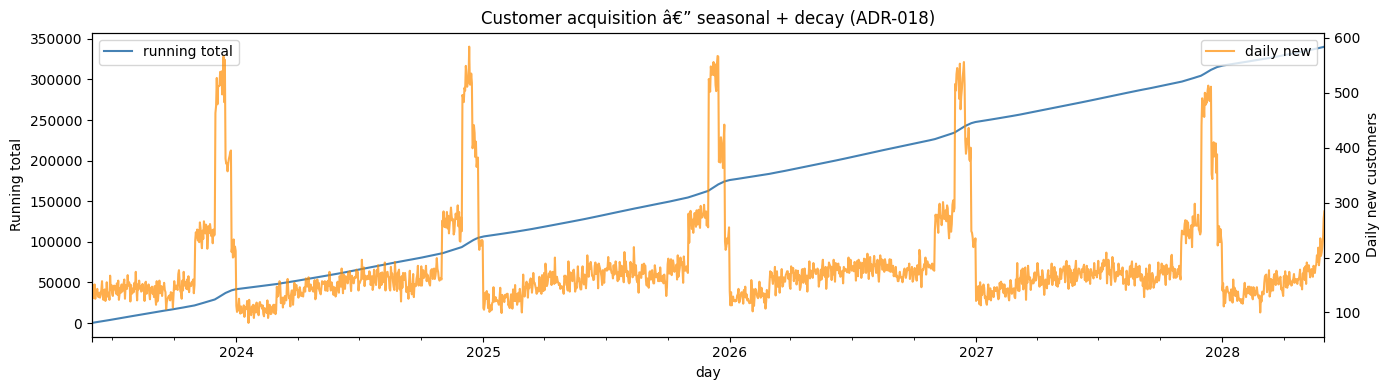

In [10]:
def generate_from_customers(df):
    dt = pd.to_datetime(df['created_at'], utc=True)
    daily = (
        dt.dt.floor('D').value_counts().sort_index()
        .reset_index().rename(columns={'created_at':'day','count':'customers'})
    )
    total = daily.assign(running_total=lambda x: x['customers'].cumsum())
    return daily, total[['day','running_total']]

daily, running = generate_from_customers(customers)

fig, ax = plt.subplots(figsize=(14, 4))
ax2 = ax.twinx()
running.set_index('day')['running_total'].plot(ax=ax, color='steelblue', label='running total')
daily.set_index('day')['customers'].plot(ax=ax2, color='darkorange', alpha=0.7, label='daily new')
ax.set_title('Customer acquisition â€” seasonal + decay (ADR-018)')
ax.set_ylabel('Running total')
ax2.set_ylabel('Daily new customers')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()


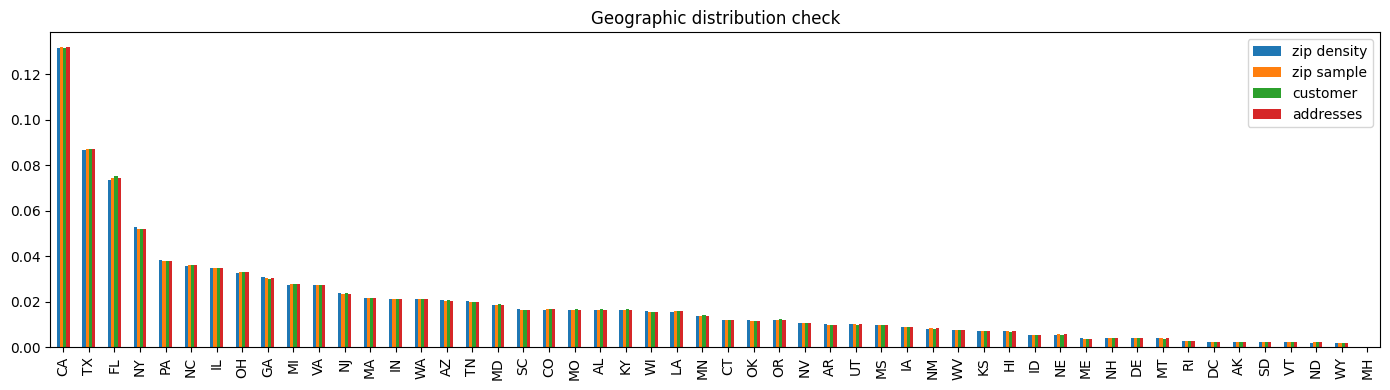

In [11]:
sample_dist   = sample.groupby('state').population.sum() / sample.shape[0]
customer_dist = customers_addresses.groupby('state').customer_id.count() / len(customers_addresses)
address_dist  = addresses.groupby('state').address_id.count() / len(addresses)

d = pd.concat([
    total_dist.rename('zip density'),
    sample_dist.rename('zip sample'),
    customer_dist.rename('customer'),
    address_dist.rename('addresses'),
], axis=1).fillna(0).sort_values('zip density', ascending=False)
d.plot.bar(figsize=(14, 4))
plt.title('Geographic distribution check')
plt.tight_layout()
plt.show()


## Products

In [12]:
import random
import string
import pandas as pd
from faker import Faker

fake = Faker()

# ---------------------------------------------------------
# 1. Expanded base product names (30Ã¢â‚¬â€œ40 per category)
# ---------------------------------------------------------
PRODUCT_BASES = {
    "Electronics": [
        "Wireless Headphones", "Bluetooth Speaker", "Smartphone Case",
        "USB-C Cable", "Portable Charger", "LED Monitor", "Webcam",
        "Gaming Mouse", "Mechanical Keyboard", "Smartwatch",
        "Noise Cancelling Earbuds", "4K Action Camera", "WiFi Router",
        "External SSD", "Laptop Stand", "HDMI Switch", "Dash Cam",
        "Bluetooth Tracker", "VR Headset", "Smart Light Bulb",
        "Portable Projector", "Soundbar", "Graphics Tablet",
        "Gaming Controller", "Wireless Charger", "Microphone",
        "Studio Headphones", "Drone Camera", "Mini Tripod",
        "Bluetooth Adapter", "USB Hub", "Ergonomic Mouse"
    ],
    "Home & Kitchen": [
        "Stainless Steel Pan", "Electric Kettle", "Vacuum Cleaner",
        "Air Fryer", "Cutlery Set", "Coffee Grinder", "Water Filter",
        "Blender", "Toaster Oven", "Rice Cooker", "Food Storage Set",
        "Chef Knife", "Pressure Cooker", "Hand Mixer", "Dish Rack",
        "Slow Cooker", "Cast Iron Skillet", "Electric Griddle",
        "Stand Mixer", "Glass Bakeware Set", "Kitchen Scale",
        "Electric Can Opener", "Food Processor", "Immersion Blender",
        "Air Purifier", "Dehumidifier", "Space Heater",
        "Electric Wine Opener", "Knife Sharpener", "Salad Spinner"
    ],
    "Beauty & Personal Care": [
        "Moisturizing Cream", "Shampoo", "Conditioner",
        "Face Serum", "Body Lotion", "Hair Dryer",
        "Beard Trimmer", "Electric Toothbrush", "Sunscreen",
        "Lip Balm", "Facial Cleanser", "Makeup Remover",
        "Face Mask", "Body Scrub", "Hair Straightener",
        "Curling Iron", "Nail Polish Set", "Beard Oil",
        "Aftershave Balm", "Anti-Aging Cream", "Eye Cream",
        "Hair Mousse", "Dry Shampoo", "Face Toner",
        "Hand Cream", "Foot Cream", "Bath Salts"
    ],
    "Sports & Outdoors": [
        "Yoga Mat", "Running Shoes", "Camping Tent",
        "Hiking Backpack", "Water Bottle", "Dumbbell Set",
        "Trekking Poles", "Sleeping Bag", "Cycling Helmet",
        "Fishing Rod", "Portable Cooler", "Kayak Paddle",
        "Camping Stove", "Climbing Rope", "Trail Running Vest",
        "Binoculars", "Hiking Boots", "Inflatable Kayak",
        "Camping Lantern", "Portable Hammock", "Snow Goggles",
        "Ski Gloves", "Swim Goggles", "Tennis Racket",
        "Pickleball Paddle", "Soccer Ball", "Basketball"
    ],
    "Toys & Games": [
        "Building Blocks", "Board Game", "Puzzle Set",
        "RC Car", "Dollhouse", "Action Figure",
        "Science Kit", "Plush Toy", "Marble Run",
        "Train Set", "Art Kit", "STEM Robot",
        "Kite Set", "Magic Kit", "Water Gun",
        "Foam Dart Blaster", "Play Kitchen", "Toy Drum Set",
        "Remote Helicopter", "Mini Drone", "Card Game",
        "Strategy Game", "Toddler Learning Blocks"
    ],
    "Office Supplies": [
        "Notebook", "Ballpoint Pen", "Desk Organizer",
        "Stapler", "Mouse Pad", "Office Chair",
        "Standing Desk", "Paper Shredder", "Whiteboard",
        "Fountain Pen", "File Cabinet", "Label Maker",
        "Desk Lamp", "Monitor Stand", "Keyboard Tray",
        "Document Scanner", "Desk Mat", "Sticky Notes",
        "Highlighter Set", "Clip Dispenser", "Desk Clock"
    ]
}

# ---------------------------------------------------------
# 2. Expanded brand list (30+ synthetic brands)
# ---------------------------------------------------------
BRANDS = [
    "Apex", "NovaTech", "BluePeak", "UrbanPro", "Silverline",
    "OmniGear", "EverBright", "Zenith", "CoreWorks", "Peakstone",
    "BrightLeaf", "Hyperion", "NorthStar", "FlexiCo", "RedRiver",
    "SkyForge", "IronClad", "PureWave", "EcoFlow", "TrueNorth",
    "PrimeEdge", "VoltX", "GearLab", "SummitPro", "CrystalTech",
    "MetroLine", "UltraCore", "BrightPath", "NextPhase", "OptiMax"
]

# ---------------------------------------------------------
# 3. Expanded modifiers (colors, materials, sizes, etc.)
# ---------------------------------------------------------
COLORS = [
    "Black", "White", "Blue", "Red", "Green", "Gray", "Silver", "Gold",
    "Navy", "Charcoal", "Rose", "Teal", "Beige"
]

EDITIONS = [
    "Pro", "XL", "Mini", "Plus", "Lite", "Max", "Ultra", "SE", "Prime"
]

PACKS = [
    "2-Pack", "3-Pack", "4-Pack", "5-Pack", "6-Pack", "10-Pack"
]

MATERIALS = [
    "Stainless Steel", "Carbon Fiber", "Bamboo", "Aluminum",
    "Titanium", "Glass", "Recycled Plastic"
]

SIZES = [
    "Small", "Medium", "Large", "Extra Large", "Compact", "Travel Size"
]

ADJECTIVES = [
    "Premium", "Advanced", "Eco-Friendly", "Portable", "Heavy-Duty",
    "Lightweight", "Ergonomic", "Smart", "Rechargeable", "Wireless"
]

MODEL_CHARS = string.ascii_uppercase + string.digits

def random_model():
    return "".join(random.choices(MODEL_CHARS, k=random.randint(3, 6)))

# ---------------------------------------------------------
# 4. Build a highly varied product name
# ---------------------------------------------------------
def generate_product_name(category):
    base = random.choice(PRODUCT_BASES[category])
    brand = random.choice(BRANDS)

    modifier = random.choice([
        "",
        random.choice(COLORS),
        random.choice(EDITIONS),
        random.choice(PACKS),
        random.choice(MATERIALS),
        random.choice(SIZES),
        random.choice(ADJECTIVES),
        f"Model {random_model()}",
        f"{random.choice(COLORS)} {random.choice(EDITIONS)}",
        f"{random.choice(ADJECTIVES)} {random.choice(SIZES)}",
        f"{random.choice(EDITIONS)} Model {random_model()}",
        f"{random.choice(MATERIALS)} Edition",
    ])

    name = f"{brand} {base}"
    if modifier:
        name += f" {modifier}"

    return name

# ---------------------------------------------------------
# 5. SKU generator
# ---------------------------------------------------------
def generate_sku(category):
    prefix = ''.join(word[0] for word in category.split()).upper()
    rand = ''.join(random.choices(string.ascii_uppercase + string.digits, k=6))
    return f"{prefix}-{rand}"

# ---------------------------------------------------------
# 6. Full product generator
# ---------------------------------------------------------
def generate_product():
    category = random.choice(list(PRODUCT_BASES.keys()))
    name = generate_product_name(category)

    price = round(random.uniform(5, 300), 2)
    cost_price = round(price * random.uniform(0.45, 0.75), 2)

    return {
        "product_id": f"prod_{fake.uuid4(cast_to=None).hex[:12]}",
        "sku": generate_sku(category),
        "name": name,
        "category": category,
        "price": price,
        "cost_price": cost_price
    }

# ---------------------------------------------------------
# 7. Generate catalog
# ---------------------------------------------------------
def generate_catalog(n=5000):
    return pd.DataFrame(generate_product() for _ in range(n))

products = generate_catalog(25000)



In [13]:
print('--- products ---')
display(cardinality_check(products))
assert products['product_id'].is_unique, 'product_id not unique'
print(f'Products: {len(products):,}')


--- products ---


,cardinality
product_id,1.00000
sku,1.00000
name,0.96600
category,0.00024
price,0.67128
cost_price,0.56532


Products: 25,000


In [14]:
print(f"""
Customers: {len(customers):>10,.0f}
Addresses: {len(addresses):>10,.0f}
Products:  {len(products):>10,.0f}
""")

for table in ['customers', 'addresses', 'products']:
    df = globals()[table]
    display(Markdown(f'### {table}'), Markdown('\n'.join(f'- `{n}` ({v})' for n, v in df.dtypes.items())))



Customers:    340,452
Addresses:    200,000
Products:      25,000



### customers

- `customer_id` (str)
- `first_name` (str)
- `last_name` (str)
- `email` (str)
- `address_id` (str)
- `created_at` (str)

### addresses

- `address_id` (str)
- `street_address` (str)
- `city` (str)
- `state` (str)
- `postal_code` (str)
- `country` (str)

### products

- `product_id` (str)
- `sku` (str)
- `name` (str)
- `category` (str)
- `price` (float64)
- `cost_price` (float64)

## Save to CSV

> Commented out for review â€” uncomment when results look good.

In [16]:
customers.to_csv('../samples/customers.csv', index=False)
addresses.to_csv('../samples/addresses.csv', index=False)
products.to_csv('../samples/products.csv',   index=False)
print('Saved.')


Saved.
